<a href="https://colab.research.google.com/github/noobcoded17/bakajuan-mobilenetv3-model/blob/main/MangroveClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================
# 0. Install Required Packages
# ====================================
!pip install --upgrade pip
!pip install tensorflow==2.16.1 matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 33.6 MB/s  0:00:10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 143.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.5 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboa

In [ ]:
# ====================================
# 1. Imports
# ====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

print("TensorFlow version:", tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.16.1


In [ ]:
# ====================================
# 2. Paths & Parameters
# ====================================
base_dir = "/content/drive/MyDrive/DATASETS"
train_dir = base_dir + "/TRAINING"
val_dir   = base_dir + "/VALIDATION"
test_dir  = base_dir + "/TEST"

img_size = (224, 224)
batch_size = 32

# ====================================
# 3. Load datasets
# ====================================
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

# Get class names
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Optimize pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.prefetch(buffer_size=AUTOTUNE)


Found 2349 files belonging to 6 classes.
Found 510 files belonging to 6 classes.
Found 510 files belonging to 6 classes.
Classes: ['BAKHAW_BABAE', 'BUTA_BUTA', 'MIYAPI', 'PAGATPAT', 'POTOTAN', 'UNKNOWN_SPECIES']


In [ ]:
# ====================================
# 4. Data Augmentation
# ====================================
def random_brightness(img):
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.random_brightness(img, max_delta=0.2)
    return img

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.Lambda(random_brightness)
])

In [ ]:
import numpy as np

epochs = 15
import os

class_counts = {}
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))
    else:
        class_counts[class_name] = 0

print("🖼️ Original images per class:")
for class_name in class_names:
    n_images = class_counts.get(class_name, 0)
    print(f"  {class_name}: {n_images} images")
print("\n🔄 Potential augmented images per class after", epochs, "epochs:")
for class_name in class_names:
    n_images = class_counts.get(class_name, 0)
    print(f"  {class_name}: {n_images * epochs} augmented images")

🖼️ Original images per class:
  BAKHAW_BABAE: 380 images
  BUTA_BUTA: 412 images
  MIYAPI: 397 images
  PAGATPAT: 366 images
  POTOTAN: 409 images
  UNKNOWN_SPECIES: 385 images

🔄 Potential augmented images per class after 15 epochs:
  BAKHAW_BABAE: 5700 augmented images
  BUTA_BUTA: 6180 augmented images
  MIYAPI: 5955 augmented images
  PAGATPAT: 5490 augmented images
  POTOTAN: 6135 augmented images
  UNKNOWN_SPECIES: 5775 augmented images


In [ ]:
# ====================================
# 5. Build Model (MobileNetV3-Small)
# ====================================
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,582 (3.60 MB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
# ====================================
# 6. Train (Warm-up)
# ====================================
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

# ====================================
# 7. Fine-tune Backbone
# ====================================
base_model.trainable = True
for layer in base_model.layers[:-50]:  # keep last 50 layers trainable
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 762s 2s/step - accuracy: 0.4127 - loss: 1.5565 - val_accuracy: 0.6275 - val_loss: 1.0780
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7438 - loss: 0.9931 - val_accuracy: 0.7098 - val_loss: 0.9901
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.8179 - loss: 0.8548 - val_accuracy: 0.7706 - val_loss: 0.9173
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - accuracy: 0.8419 - loss: 0.7968 - val_accuracy: 0.8294 - val_loss: 0.8082
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.8665 - loss: 0.7679 - val_accuracy: 0.7980 - val_loss: 0.8676
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.8779 - loss: 0.7275 - val_accuracy: 0.8098 - val_loss: 0.8447
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8952 - loss: 0.7231 - val_accuracy: 0.8196 - val_loss: 0.8155
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.8786 - loss: 0.7196 - val_accuracy: 0.8196 - v

In [ ]:
#====================================
# 8. Temperature Scaling
# ====================================
import tensorflow as tf
import tensorflow.keras.backend as K

class TemperatureScaledModel(tf.keras.Model):
    def __init__(self, base_model, temperature=1.0):
        super().__init__()
        self.base_model = base_model
        self.temperature = tf.Variable(initial_value=temperature, trainable=True, dtype=tf.float32)

    def call(self, inputs):
        logits = self.base_model(inputs)  # raw outputs (before softmax)
        return tf.nn.softmax(logits / self.temperature)

# Wrap the fine-tuned model
temp_scaled_model = TemperatureScaledModel(model, temperature=1.0)

# Compile (only temperature is trainable here)
temp_scaled_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Calibrate temperature using validation data
temp_scaled_model.fit(
    val_ds,
    epochs=3
)

model = temp_scaled_model

Epoch 1/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9331 - loss: 1.2297
Epoch 2/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9563 - loss: 1.1432
Epoch 3/3
16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.9769 - loss: 1.0923


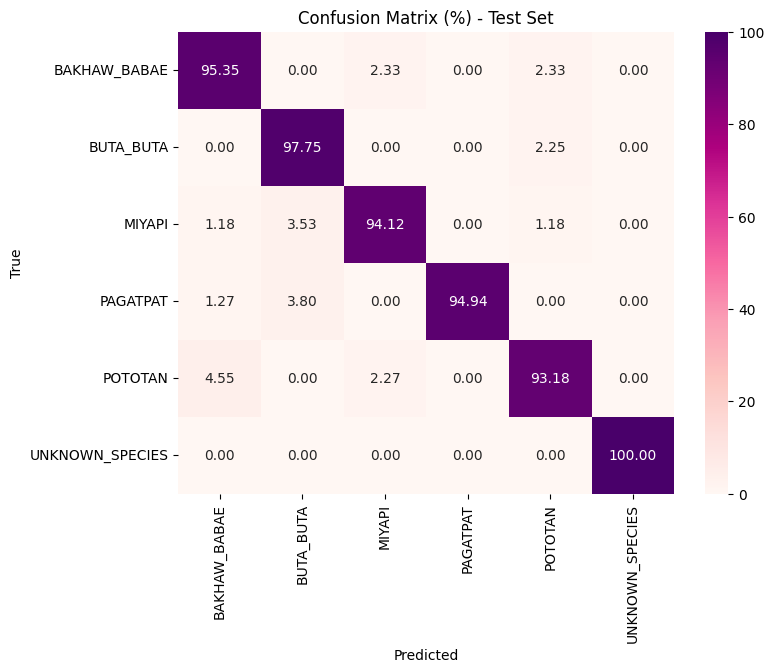


📊 Classification Report (Test Set):

                 precision    recall  f1-score   support

   BAKHAW_BABAE     0.9318    0.9535    0.9425        86
      BUTA_BUTA     0.9355    0.9775    0.9560        89
         MIYAPI     0.9524    0.9412    0.9467        85
       PAGATPAT     1.0000    0.9494    0.9740        79
        POTOTAN     0.9425    0.9318    0.9371        88
UNKNOWN_SPECIES     1.0000    1.0000    1.0000        83

       accuracy                         0.9588       510
      macro avg     0.9604    0.9589    0.9594       510
   weighted avg     0.9594    0.9588    0.9589       510


✅ Test Accuracy: 95.88%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Collect predictions
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix (percentages)
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="RdPu",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) - Test Set")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n📊 Classification Report (Test Set):\n")
print(report)

# Overall Accuracy
test_acc = accuracy_score(y_true, y_pred) * 100
print(f"\n✅ Test Accuracy: {test_acc:.2f}%")

In [ ]:
print("Warm-up Training Accuracy:", history.history["accuracy"][-1])
print("Warm-up Validation Accuracy:", history.history["val_accuracy"][-1])

print("Fine-tune Training Accuracy:", fine_tune_history.history["accuracy"][-1])
print("Fine-tune Validation Accuracy:", fine_tune_history.history["val_accuracy"][-1])

train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(val_ds)

print(f"Temperature-scaled Training Accuracy: {train_acc:.4f}")
print(f"Temperature-scaled Validation Accuracy: {val_acc:.4f}")


Warm-up Training Accuracy: 0.9152830839157104
Warm-up Validation Accuracy: 0.8549019694328308
Fine-tune Training Accuracy: 0.8769689202308655
Fine-tune Validation Accuracy: 0.8764705657958984
74/74 ━━━━━━━━━━━━━━━━━━━━ 257s 737ms/step - accuracy: 0.9316 - loss: 1.1241
16/16 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.9781 - loss: 1.0819
Temperature-scaled Training Accuracy: 0.9417
Temperature-scaled Validation Accuracy: 0.9745


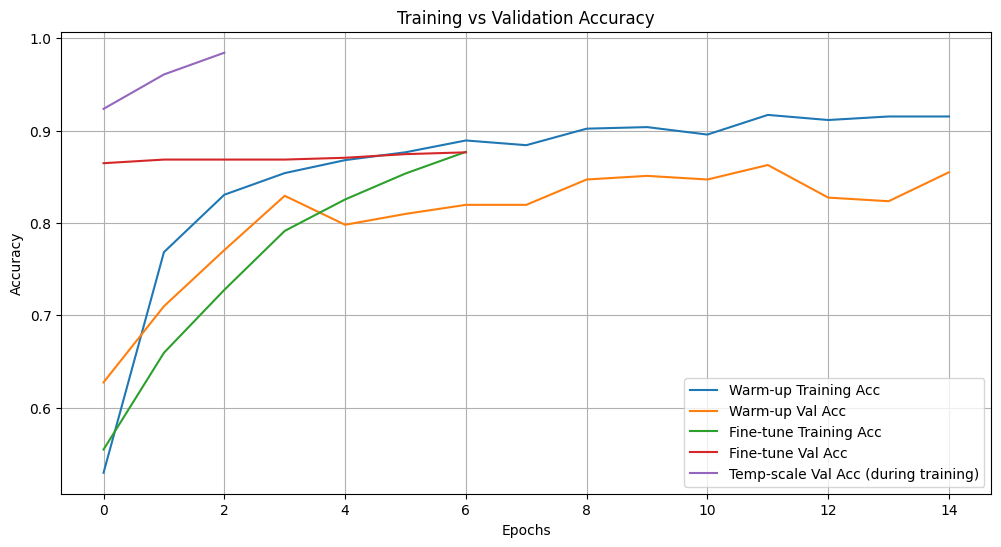

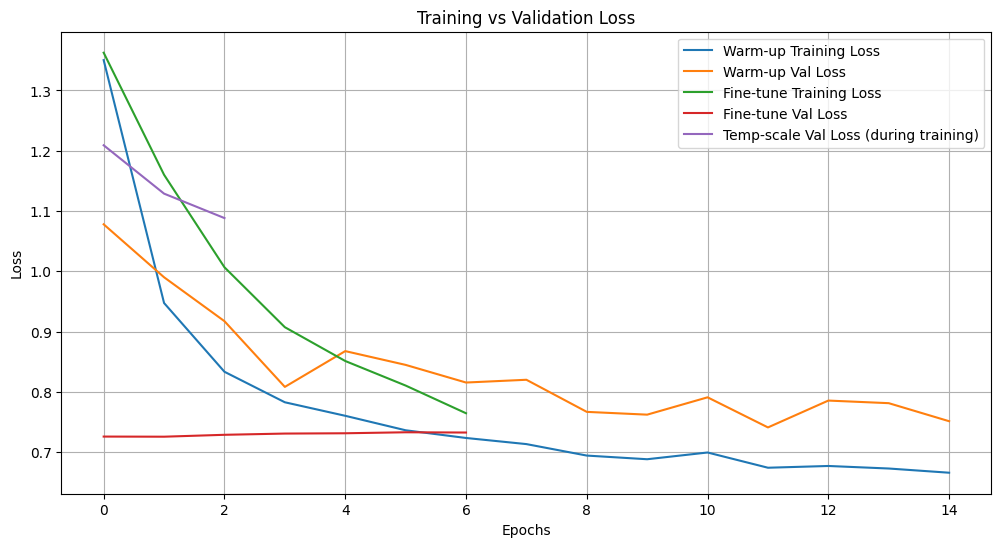

In [ ]:
import matplotlib.pyplot as plt

# ====================================
# 1. Warm-up history
# ====================================
plt.figure(figsize=(12,6))

plt.plot(history.history["accuracy"], label="Warm-up Training Acc")
plt.plot(history.history["val_accuracy"], label="Warm-up Val Acc")

# ====================================
# 2. Fine-tune history
# ====================================
plt.plot(fine_tune_history.history["accuracy"], label="Fine-tune Training Acc")
plt.plot(fine_tune_history.history["val_accuracy"], label="Fine-tune Val Acc")

# ====================================
# 3. Temperature scaling history
# ====================================

plt.plot(temp_scaled_model.history.history["accuracy"], label="Temp-scale Val Acc (during training)")

# ====================================
# Final touches
# ====================================
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# You might also want to plot the loss history for all stages
plt.figure(figsize=(12,6))
plt.plot(history.history["loss"], label="Warm-up Training Loss")
plt.plot(history.history["val_loss"], label="Warm-up Val Loss")
plt.plot(fine_tune_history.history["loss"], label="Fine-tune Training Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Fine-tune Val Loss")
plt.plot(temp_scaled_model.history.history["loss"], label="Temp-scale Val Loss (during training)")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================
# 9. Export, Convert, and Save as TFLite
# ====================================

inputs = tf.keras.Input(shape=img_size + (3,), name='input')
x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input, name='preprocessing')(inputs)
x = model.base_model.layers[2](x) # Use the base_model from the trained model (mobilenet_v3_small)
x = model.base_model.layers[3](x) # Use the GlobalAveragePooling2D layer
x = model.base_model.layers[4](x) # Use the Dropout layer
outputs = model.base_model.layers[-1](x) # Use the final Dense layer

tflite_model_for_export = tf.keras.Model(inputs=inputs, outputs=outputs)

# Note: The weights are automatically transferred as we are using the layers
# directly from the trained 'model' object.

# Export the new model as a SavedModel
export_dir = "/content/drive/MyDrive/MLMODEL/final_mangrove_model_for_tflite"
tflite_model_for_export.export(export_dir) # Use model.export() for SavedModel format

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

# Save as .tflite file
tflite_file_path = "/content/drive/MyDrive/MLMODEL/backup_model3.tflite"
with open(tflite_file_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ TFLite model saved at: {tflite_file_path}")

Saved artifact at '/content/drive/MyDrive/MLMODEL/final_mangrove_model_for_tflite'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140280748416208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748416400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748417360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748416976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748417168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748417744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748417936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748416592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748417552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140280748418512: TensorSpec(shape=(), dtype=t

In [ ]:
import os
import pandas as pd

# Epochs
warmup_epochs = 15
finetune_epochs = 6
tempscale_epochs = 3

# Count images per class
class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(train_dir, class_name)
    if os.path.isdir(class_dir):
        class_counts[class_name] = len(os.listdir(class_dir))
    else:
        class_counts[class_name] = 0

# Build table data
data = []
for class_name, n_images in class_counts.items():
    warmup_aug = n_images * warmup_epochs
    finetune_aug = n_images * finetune_epochs
    tempscale_aug = n_images * tempscale_epochs
    total_aug = warmup_aug + finetune_aug + tempscale_aug
    data.append([class_name, n_images, warmup_aug, finetune_aug, tempscale_aug, total_aug])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Class", "Original Images",
    f"Warm-up ({warmup_epochs})",
    f"Fine-tune ({finetune_epochs})",
    f"Temp Scale ({tempscale_epochs})",
    "Total Seen"
])

# Display table
print(df.to_string(index=False))


          Class  Original Images  Warm-up (15)  Fine-tune (6)  Temp Scale (3)  Total Seen
   BAKHAW_BABAE              380          5700           2280            1140        9120
      BUTA_BUTA              412          6180           2472            1236        9888
         MIYAPI              397          5955           2382            1191        9528
       PAGATPAT              366          5490           2196            1098        8784
        POTOTAN              409          6135           2454            1227        9816
UNKNOWN_SPECIES              385          5775           2310            1155        9240


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ================================
# Upload local image
# ================================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ================================
# Prediction function with threshold
# ================================
def predict_tflite(image_path, threshold=0.7):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    input_data = np.expand_dims(np.array(img, dtype=np.float32), axis=0)

    # Run TFLite inference
    interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/MLMODEL/trial_model2.tflite")
    interpreter.allocate_tensors()

    input_index = interpreter.get_input_details()[0]['index']
    output_index = interpreter.get_output_details()[0]['index']

    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_index)[0]

    # Get best class
    class_id = np.argmax(preds)
    confidence = preds[class_id]

    # ================================
    # Apply threshold check
    # ================================
    if confidence >= threshold:
        prediction_text = f"{class_names[class_id]} ({confidence:.2f})"
    else:
        prediction_text = f"Image Not Recognized ({confidence:.2f})"

    # Display image with prediction
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {prediction_text}")
    plt.show()

    return class_id, confidence, prediction_text

# ================================
# Run prediction
# ================================
class_id, conf, pred_text = predict_tflite(image_path, threshold=0.6)
print(f"✅ Result: {pred_text}")


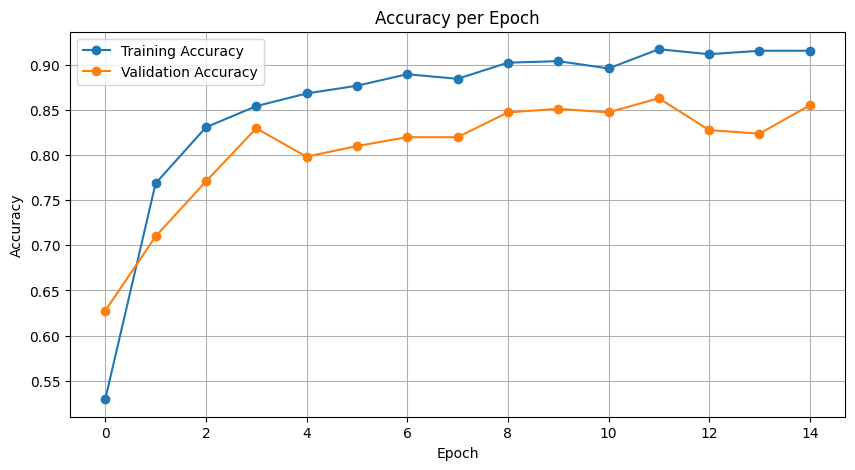

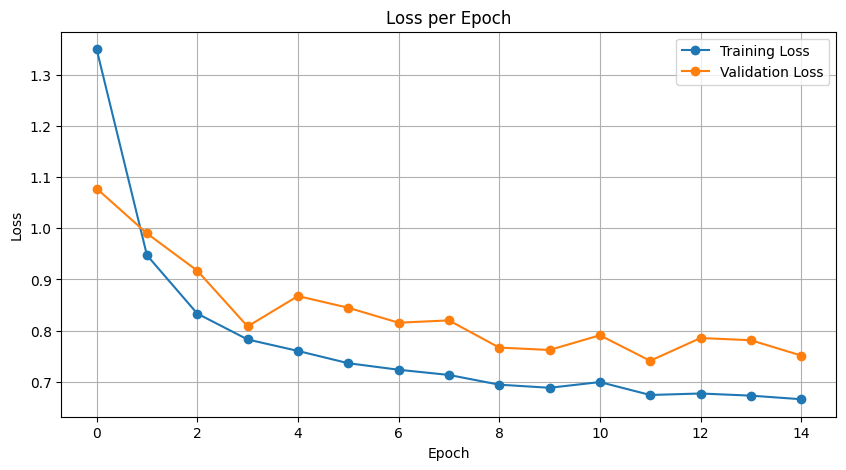

In [ ]:
import matplotlib.pyplot as plt


# --- Accuracy per epoch ---
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Loss per epoch ---
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#================================#================================#================================#================================#================================
#================================#================================#================================#================================#================================
#================================#================================#================================#================================#================================
#================================#================================#================================#================================#================================
#================================#================================#================================#================================#================================
#================================#================================#================================#================================#================================

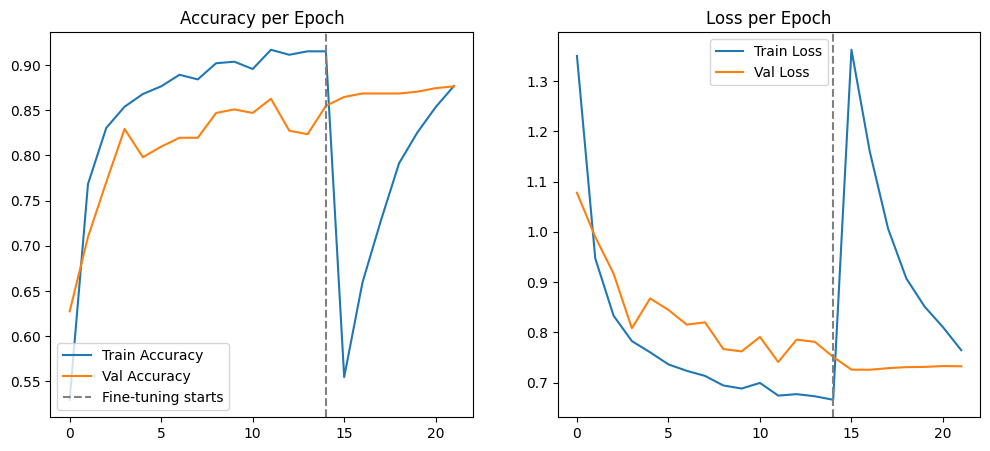

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history1, history2):
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(acc, label="Train Accuracy")
    plt.plot(val_acc, label="Val Accuracy")
    plt.axvline(x=len(history1.history['accuracy'])-1, color='gray', linestyle='--', label="Fine-tuning starts")
    plt.legend()
    plt.title("Accuracy per Epoch")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.axvline(x=len(history1.history['loss'])-1, color='gray', linestyle='--')
    plt.legend()
    plt.title("Loss per Epoch")

    plt.show()

plot_history(history, fine_tune_history)
